Deep Learning Project

# Spotify Tracks Data

## Refinement

## Last refined: 4/21/26

## Data Pipeline and Refiment

Import Libraries

In [38]:
import matplotlib.pyplot as plt
import kagglehub
import os
import pandas as pd
import numpy as np
import shap
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go

from sklearn.manifold import TSNE
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import multilabel_confusion_matrix, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve, auc
from sklearn.utils import class_weight
from sklearn.metrics.pairwise import cosine_similarity


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau





In [2]:
# Download Latest
path = kagglehub.dataset_download("saichaitanyareddyai/spotify-tracks-dataset-audio-features")

print("Path to dataset files:", path)

100%|██████████| 7.90M/7.90M [00:01<00:00, 7.16MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features/versions/1


## Model Architecture and Task

In [3]:


# Show files downloaded
print("Files in dataset folder:")
print(os.listdir(path))

# Build full CSV path
csv_path = os.path.join(path, "spotify-tracks-dataset-detailed.csv")
print("CSV path:", csv_path)

# Load dataset
df = pd.read_csv(csv_path)

# Basic shape
print("Dataset shape:", df.shape)

# First few rows
df.head()

Files in dataset folder:
['spotify-tracks-dataset-detailed.csv']
CSV path: /root/.cache/kagglehub/datasets/saichaitanyareddyai/spotify-tracks-dataset-audio-features/versions/1/spotify-tracks-dataset-detailed.csv
Dataset shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# --- REFINED DATA PREPARATION (DEEP LEARNING APPROACH) ---
# 1. Fresh copy
data = df.copy().dropna()

# 1. Get every unique genre in the dataset
all_genres = data['track_genre'].unique()

# 2. Expanded Mapping (Template - fill in the rest of the 114)
genre_mapping = {
    # 1. Acoustic/Folk (Natural/Organic instruments)
    'acoustic': 'Acoustic/Folk', 'folk': 'Acoustic/Folk', 'bluegrass': 'Acoustic/Folk',
    'world-music': 'Acoustic/Folk', 'singer-songwriter': 'Acoustic/Folk', 'forro': 'Acoustic/Folk',
    'guitar': 'Acoustic/Folk', 'honky-tonk': 'Acoustic/Folk', 'indian': 'Acoustic/Folk',
    'iranian': 'Acoustic/Folk', 'mpb': 'Acoustic/Folk', 'pagode': 'Acoustic/Folk',
    'samba': 'Acoustic/Folk', 'sertanejo': 'Acoustic/Folk', 'songwriter': 'Acoustic/Folk',
    'tango': 'Acoustic/Folk', 'turkish': 'Acoustic/Folk', 'brazil': 'Acoustic/Folk',
    'country': 'Acoustic/Folk',

    # 2. Blues/Jazz (Groove & Soul based)
    'blues': 'Blues/Jazz', 'jazz': 'Blues/Jazz', 'soul': 'Blues/Jazz', 'r-n-b': 'Blues/Jazz',
    'funk': 'Blues/Jazz', 'gospel': 'Blues/Jazz', 'groove': 'Blues/Jazz', 'reggae': 'Blues/Jazz',

    # 3. Classical (High Dynamic Range / Orchestral)
    'classical': 'Classical', 'opera': 'Classical', 'piano': 'Classical',

    # 4. Electronic (Synthesized/Drum Machine)
    'ambient': 'Electronic', 'breakbeat': 'Electronic', 'chill': 'Electronic', 'club': 'Electronic',
    'deep-house': 'Electronic', 'disco': 'Electronic', 'drum-and-bass': 'Electronic', 'dub': 'Electronic',
    'dubstep': 'Electronic', 'electro': 'Electronic', 'electronic': 'Electronic', 'garage': 'Electronic',
    'hardstyle': 'Electronic', 'house': 'Electronic', 'idm': 'Electronic', 'industrial': 'Electronic',
    'minimal-techno': 'Electronic', 'new-age': 'Electronic', 'progressive-house': 'Electronic',
    'sleep': 'Electronic', 'study': 'Electronic', 'trance': 'Electronic', 'trip-hop': 'Electronic',
    'techno': 'Electronic', 'chicago-house': 'Electronic', 'detroit-techno': 'Electronic',
    'dance': 'Electronic', 'edm': 'Electronic',

    # 5. Hip-Hop/Rap (Rhythmic/Speech based)
    'hip-hop': 'Hip-Hop/Rap', 'rap': 'Hip-Hop/Rap', 'reggaeton': 'Hip-Hop/Rap', 'dancehall': 'Hip-Hop/Rap',

    # 6. Pop (Commercial/Melodic)
    'afrobeat': 'Pop', 'anime': 'Pop', 'british': 'Pop', 'cantopop': 'Pop', 'disney': 'Pop',
    'french': 'Pop', 'german': 'Pop', 'happy': 'Pop', 'j-dance': 'Pop', 'j-idol': 'Pop',
    'j-pop': 'Pop', 'kids': 'Pop', 'latin': 'Pop', 'latino': 'Pop', 'malay': 'Pop',
    'mandopop': 'Pop', 'party': 'Pop', 'pop': 'Pop', 'pop-film': 'Pop', 'power-pop': 'Pop',
    'romance': 'Pop', 'sad': 'Pop', 'salsa': 'Pop', 'show-tunes': 'Pop', 'swedish': 'Pop',
    'synth-pop': 'Pop', 'k-pop': 'Pop',

    # 7. Rock (Distorted/Electric Guitar based)
    'alt-rock': 'Rock', 'alternative': 'Rock', 'black-metal': 'Rock', 'death-metal': 'Rock',
    'emo': 'Rock', 'goth': 'Rock', 'grindcore': 'Rock', 'grunge': 'Rock', 'hard-rock': 'Rock',
    'heavy-metal': 'Rock', 'j-rock': 'Rock', 'metal': 'Rock', 'metalcore': 'Rock',
    'psych-rock': 'Rock', 'punk': 'Rock', 'punk-rock': 'Rock', 'rock': 'Rock',
    'rock-n-roll': 'Rock', 'rockabilly': 'Rock', 'ska': 'Rock', 'hardcore': 'Rock'
}
# Apply and Default
data['genre_family'] = data['track_genre'].map(genre_mapping).fillna('Other/Indie')

# 3. Define X (Raw Features Only)
feature_cols = ['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
                'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
X = data[feature_cols]

# 4. Define y (Multi-Label Binarizer)
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(data['genre_family'].apply(lambda x: [x]))

# 5. Split and Scale
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X and y defined successfully! Prepared {X_train_scaled.shape[0]} songs.")

X and y defined successfully! Prepared 72959 songs.


In [5]:
# Validation check for your report
unmapped_count = data[data['genre_family'] == 'Other/Indie']['track_genre'].nunique()
print(f"Unique genres still in 'Other': {unmapped_count}")
print(data[data['genre_family'] == 'Other/Indie']['track_genre'].unique())

Unique genres still in 'Other': 5
['children' 'comedy' 'indie-pop' 'indie' 'spanish']


In [6]:
# Validation check
print(f"Total Songs: {len(data)}")
print(data['genre_family'].value_counts())

Total Songs: 113999
genre_family
Electronic       28000
Pop              26999
Rock             21000
Acoustic/Folk    19000
Blues/Jazz        8000
Other/Indie       5000
Classical         3000
Hip-Hop/Rap       3000
Name: count, dtype: int64


In [7]:
# Column names
print(df.columns.tolist())

# Missing values
print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False))

# Data types
print("\nData types:")
print(df.dtypes)

['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Missing values by column:
artists             1
album_name          1
track_name          1
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Data types:
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              f

In [8]:
# Check which genres are defaulting to 'Other/Indie'
unmapped = data[data['genre_family'] == 'Other/Indie']['track_genre'].unique()
print(f"Unmapped Sub-genres: {unmapped}")

Unmapped Sub-genres: ['children' 'comedy' 'indie-pop' 'indie' 'spanish']


## Training Model and Baseline

In [9]:
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation="relu"), # Extra layer for complex genre intersections
    layers.Dense(y_train.shape[1], activation="sigmoid")
])
# 1. THE FOCAL LOSS UPGRADE
# Focal loss forces the model to stop ignoring minority classes
focal_loss = tf.keras.losses.BinaryFocalCrossentropy(
    apply_class_balancing=False, # We are already using class_weight in model.fit
    gamma=2.0,                   # Focuses the model on hard-to-predict genres
)

opt = keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=opt,
    loss=focal_loss,             # Replaces standard "binary_crossentropy"
    metrics=["accuracy"]
)

#initialize
weights_per_genre = {}

for i, genre in enumerate(mlb.classes_):
    counts = np.bincount(y_train[:, i])
    # Weight = Total / (2 * count of positive samples)
    weights_per_genre[i] = len(y_train) / (2.0 * counts[1]) if counts[1] > 0 else 1.0

print("Calculated Weights:", weights_per_genre)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]


# Train the model
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=128,
    class_weight=weights_per_genre,
    callbacks=callbacks,
    verbose=1
)

# --- OPTIMIZED EVALUATION (Dynamic Thresholds) ---
# 1. Get probabilities for the validation set
y_val_probs = model.predict(X_val_scaled)

# 2. Find optimal thresholds per genre
best_thresholds = []
for i in range(len(mlb.classes_)):
    thresholds = np.linspace(0, 1, 100)
    # Find threshold that maximizes F1 for this specific genre
    f1_scores = [f1_score(y_val[:, i], (y_val_probs[:, i] > t).astype(int), zero_division=0) for t in thresholds]
    best_thresholds.append(thresholds[np.argmax(f1_scores)])

# Display findings
for genre, t in zip(mlb.classes_, best_thresholds):
    print(f"Optimal Threshold for {genre}: {t:.2f}")

# 3. Apply to Test Set
y_test_probs = model.predict(X_test_scaled)
y_pred = (y_test_probs > best_thresholds).astype(int)

# 4. Optimized Evaluation (Dynamic Thresholds)
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

Calculated Weights: {0: np.float64(2.966777813923227), 1: np.float64(7.229389615537059), 2: np.float64(18.66914022517912), 3: np.float64(2.0428683429467434), 4: np.float64(19.260559662090813), 5: np.float64(11.551456618112729), 6: np.float64(2.105477317326561), 7: np.float64(2.7166741137920765)}
Epoch 1/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.3086 - loss: 0.4015 - val_accuracy: 0.3818 - val_loss: 0.0834 - learning_rate: 5.0000e-04
Epoch 2/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3511 - loss: 0.3318 - val_accuracy: 0.3766 - val_loss: 0.0828 - learning_rate: 5.0000e-04
Epoch 3/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3664 - loss: 0.3191 - val_accuracy: 0.3803 - val_loss: 0.0819 - learning_rate: 5.0000e-04
Epoch 4/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3744 - loss: 0.3131 - val_accuracy: 0.3900 - val_loss: 0.0815 - learning_rate: 5.0000e-04
Epoch 5/50
570/570 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.3801 - 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 521,882 (1.99 MB)

 Trainable params: 173,448 (677.53 KB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 346,898 (1.32 MB)

In [10]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)
print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

Test MSE: 0.0765761062502861
Test MAE: 0.42565789818763733


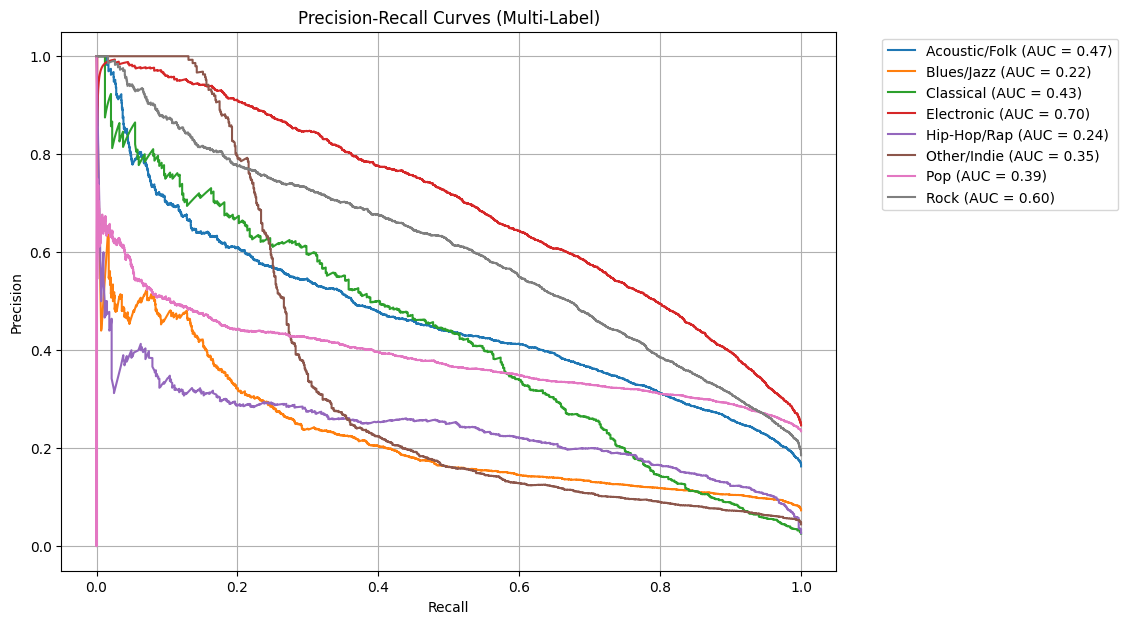

In [11]:
plt.figure(figsize=(10, 7))
for i in range(len(mlb.classes_)):
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_test_probs[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{mlb.classes_[i]} (AUC = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves (Multi-Label)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

## Visualize Result

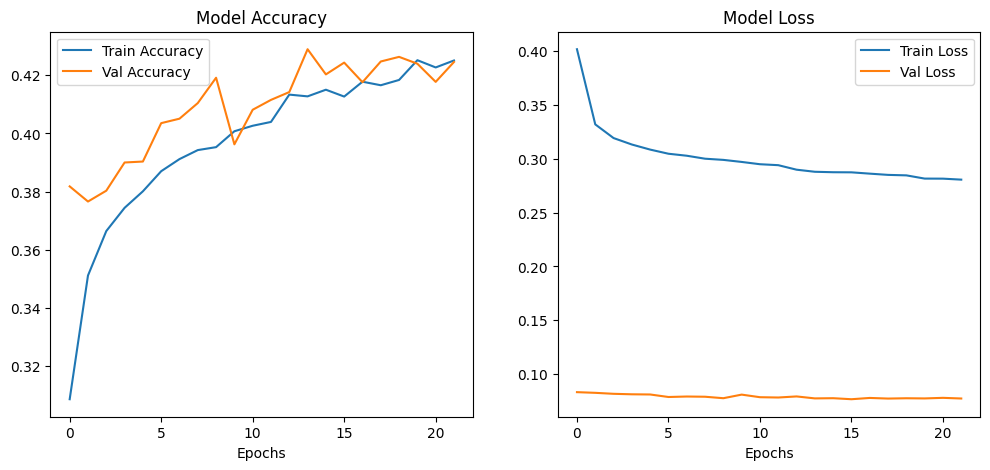

In [12]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.legend()

plt.show()

## DNA Genre Tool

In [43]:
def get_genre_dna(test_index):
    # 1. Actual Labels
    # y_test[test_index] is now a row of 0s and 1s
    actual_labels = mlb.inverse_transform(y_test[test_index:test_index+1])[0]

    # 2. Predict probabilities
    probs = model.predict(X_test_scaled[test_index:test_index+1])[0]

    # 3. Get the top 3 matches
    top_indices = np.argsort(probs)[-3:][::-1]
    top_genres = mlb.classes_[top_indices]
    top_probs = probs[top_indices]

    print(f"--- Music DNA for Test Song #{test_index} ---")
    print(f"Actual Label: {', '.join(actual_labels)}")
    print("\nModel's Top 3 Predictions:")
    for genre, p in zip(top_genres, top_probs):
        print(f"🧬 {genre}: {p*100:.2f}%")

# Test
get_genre_dna(42)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
--- Music DNA for Test Song #42 ---
Actual Label: Blues/Jazz

Model's Top 3 Predictions:
🧬 Electronic: 63.00%
🧬 Pop: 34.34%
🧬 Blues/Jazz: 25.78%


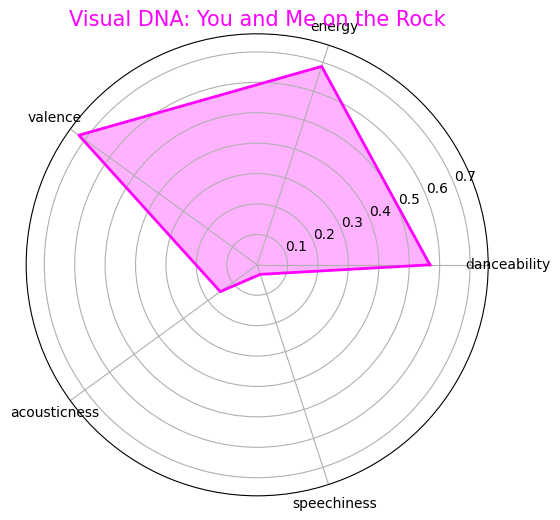

In [14]:

def plot_visual_dna(test_index):
    # The 'Nucleotides' of your Music DNA
    features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    values = data.iloc[test_index][features].values
    song_name = data.iloc[test_index]['track_name']

    # Create the Radar Chart
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    values = np.concatenate((values, [values[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.fill(angles, values, color='magenta', alpha=0.3)
    ax.plot(angles, values, color='magenta', linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)

    plt.title(f"Visual DNA: {song_name}", size=15, color='magenta')
    plt.show()

# Run from previous tested song
plot_visual_dna(42)

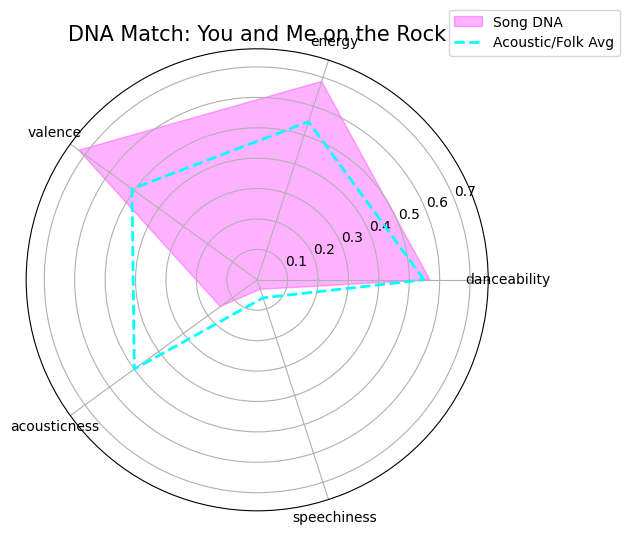

In [15]:
def plot_dna_comparison(test_index):
    features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness']
    song_data = data.iloc[test_index]
    actual_family = song_data['genre_family']

    # Get the average DNA for this entire Genre Family
    family_avg = data[data['genre_family'] == actual_family][features].mean().values
    song_values = song_data[features].values

    # Setup plot
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # Plot Song DNA
    ax.fill(angles, np.concatenate((song_values, [song_values[0]])), color='magenta', alpha=0.3, label="Song DNA")
    # Plot Genre Average DNA
    ax.plot(angles, np.concatenate((family_avg, [family_avg[0]])), color='cyan', linestyle='--', linewidth=2, label=f"{actual_family} Avg")

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.title(f"DNA Match: {song_data['track_name']}", size=15)
    plt.show()

plot_dna_comparison(42)

713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


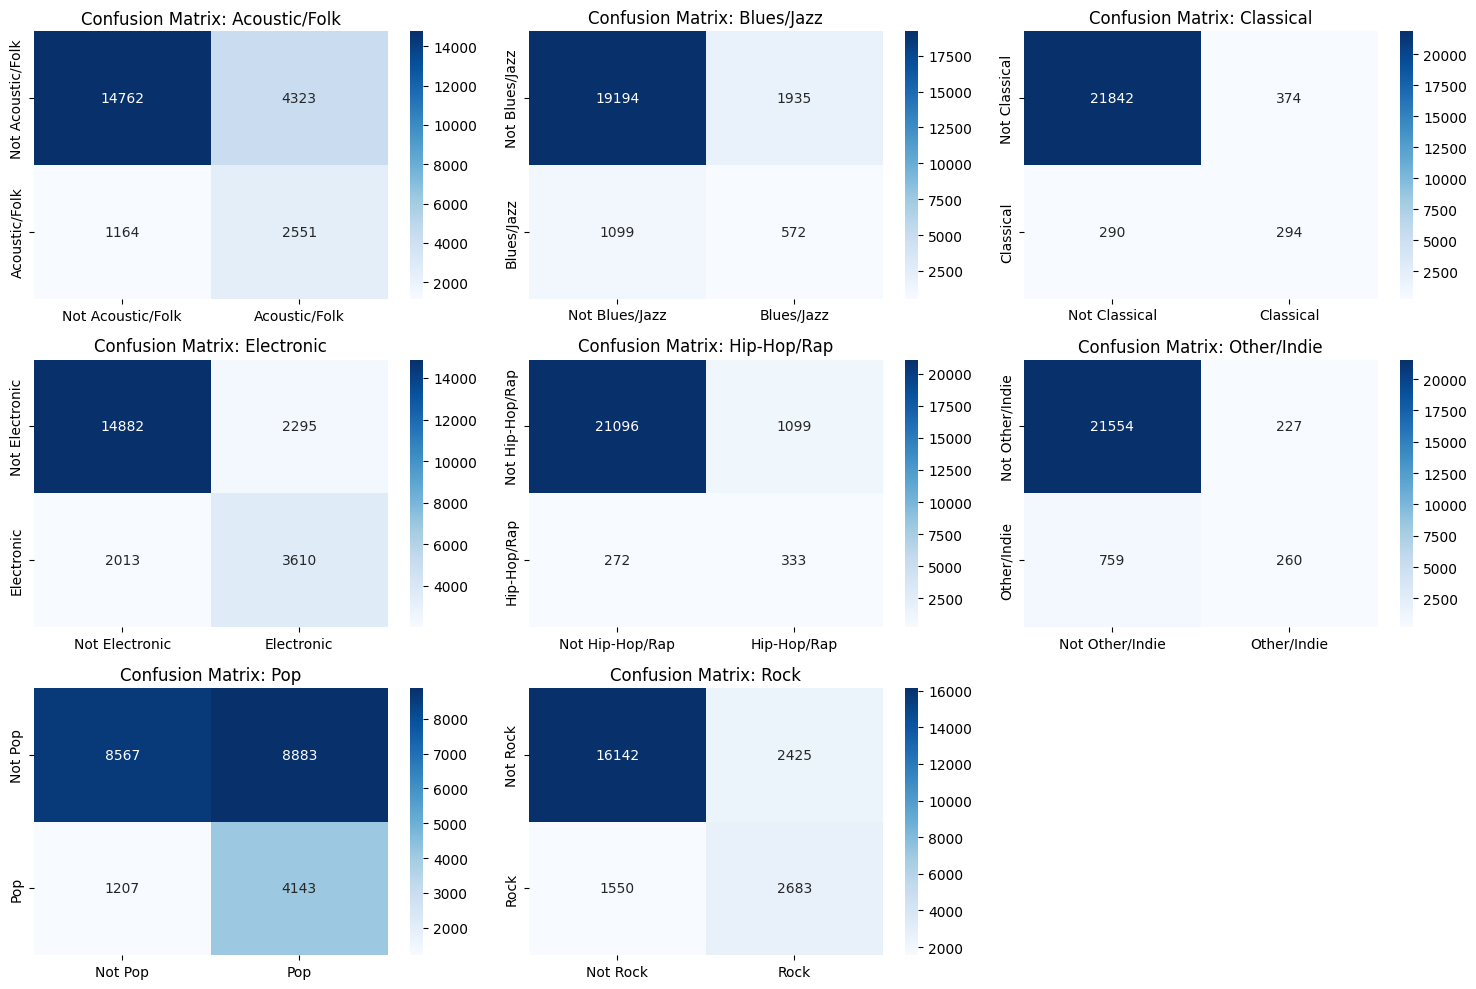

               precision    recall  f1-score   support

Acoustic/Folk       0.37      0.69      0.48      3715
   Blues/Jazz       0.23      0.34      0.27      1671
    Classical       0.44      0.50      0.47       584
   Electronic       0.61      0.64      0.63      5623
  Hip-Hop/Rap       0.23      0.55      0.33       605
  Other/Indie       0.53      0.26      0.35      1019
          Pop       0.32      0.77      0.45      5350
         Rock       0.53      0.63      0.57      4233

    micro avg       0.40      0.63      0.49     22800
    macro avg       0.41      0.55      0.44     22800
 weighted avg       0.44      0.63      0.50     22800
  samples avg       0.43      0.63      0.49     22800



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
# 1. Get predictions (probabilities)
y_pred_probs = model.predict(X_test_scaled)

# 2. Convert probabilities to hard 0s and 1s (using 0.5 threshold)
y_pred = (y_pred_probs > best_thresholds).astype(int)

# 3. Generate the matrices
matrices = multilabel_confusion_matrix(y_test, y_pred)

# 4. Plot a few key genres to see the "hits" and "misses"
plt.figure(figsize=(15, 10))
for i, genre in enumerate(mlb.classes_):
    plt.subplot(3, 3, i+1)
    sns.heatmap(matrices[i], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not ' + genre, genre],
                yticklabels=['Not ' + genre, genre])
    plt.title(f'Confusion Matrix: {genre}')

plt.tight_layout()
plt.show()

# 5. Print the full text report for precision/recall
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

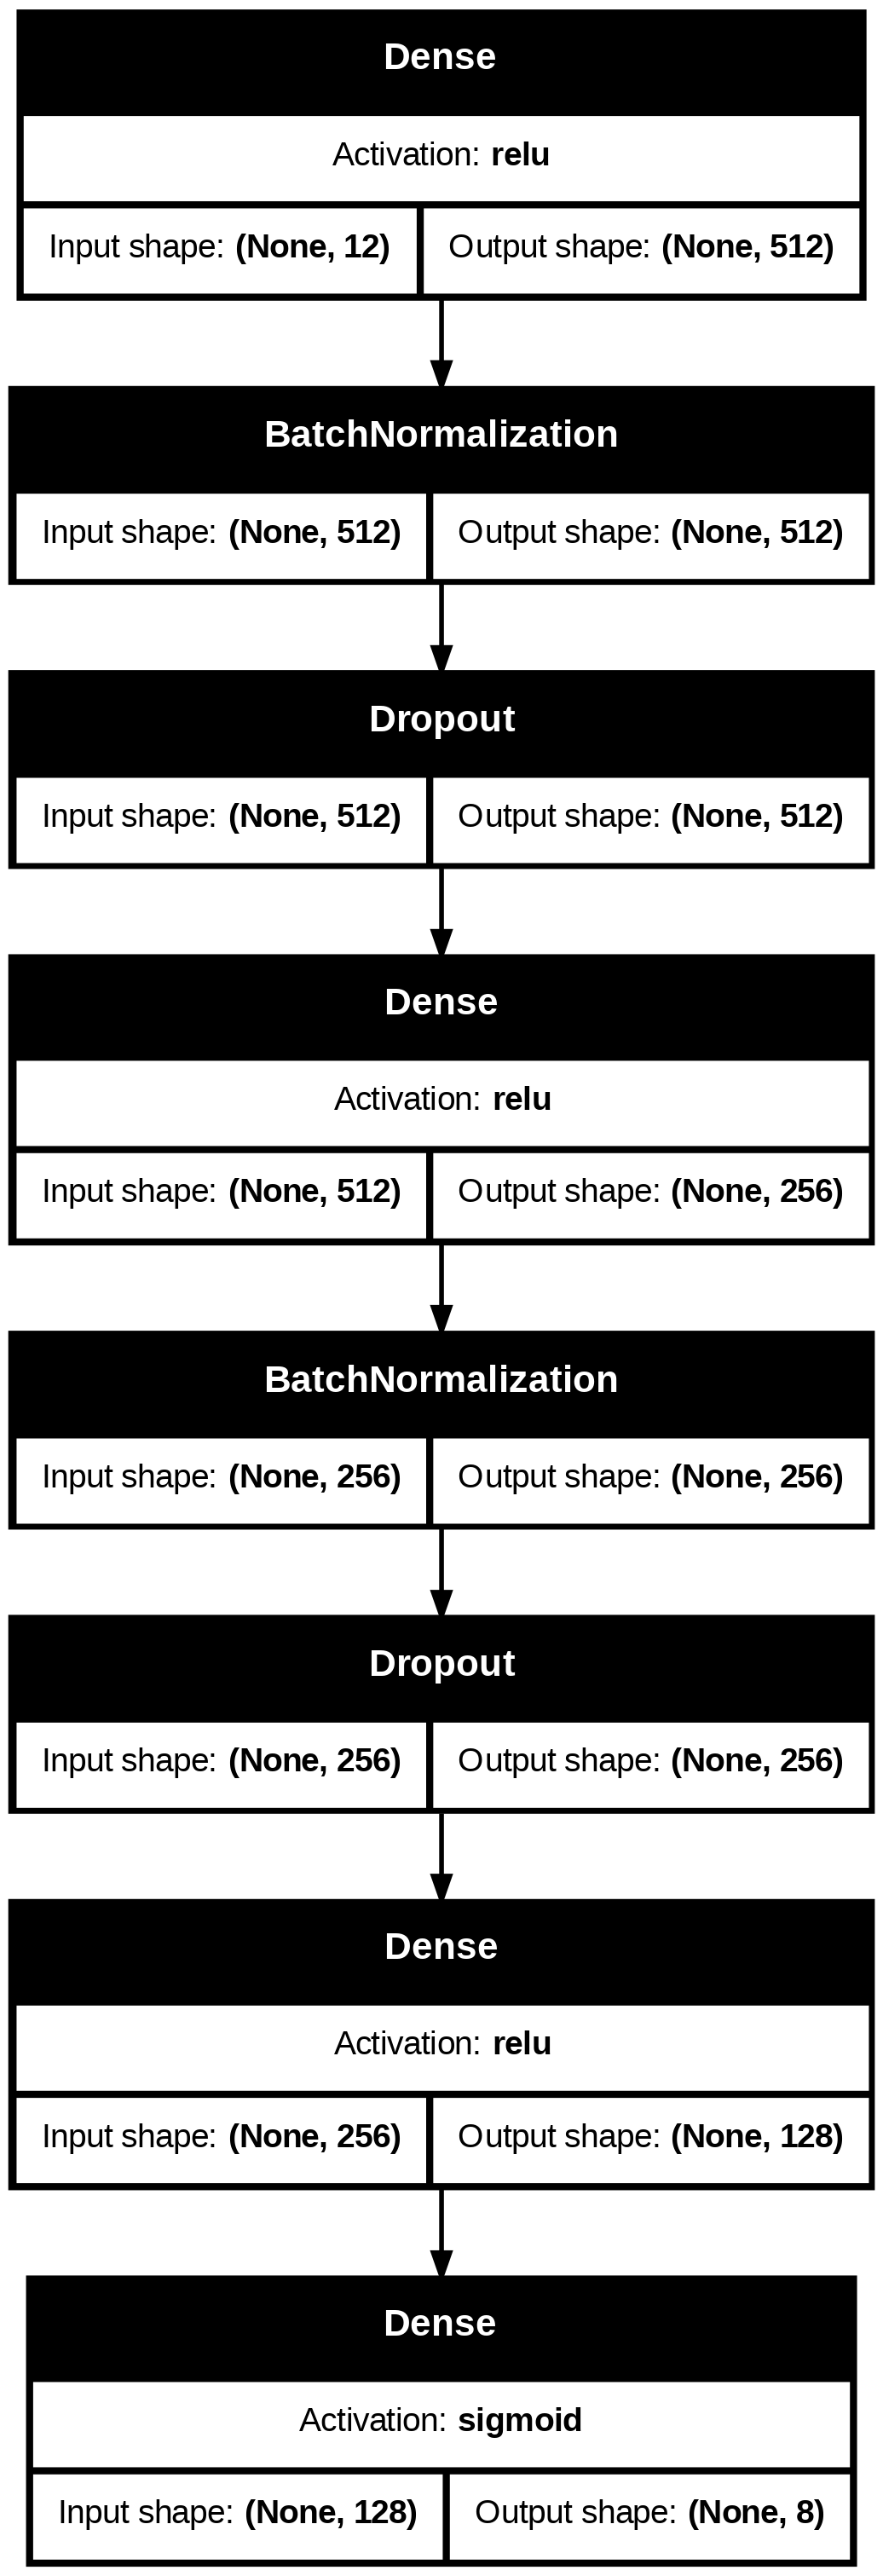

In [17]:

plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_activations=True)

In [18]:
# Create a balanced subset for visualization ONLY
# Prevents 'Other/Indie' from crowding Latent Space
sample_per_genre = 500
df_balanced = data.groupby('genre_family').apply(lambda x: x.sample(n=min(len(x), sample_per_genre))).reset_index(drop=True)

# Update your X_visual and y_visual variables
X_visual = scaler.transform(df_balanced[feature_cols])
y_visual_labels = df_balanced['genre_family']

print(f"Balanced visualization dataset created with {len(df_balanced)} samples.")

Balanced visualization dataset created with 4000 samples.


/tmp/ipykernel_8137/2629099123.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = data.groupby('genre_family').apply(lambda x: x.sample(n=min(len(x), sample_per_genre))).reset_index(drop=True)


## TSNE Plot

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


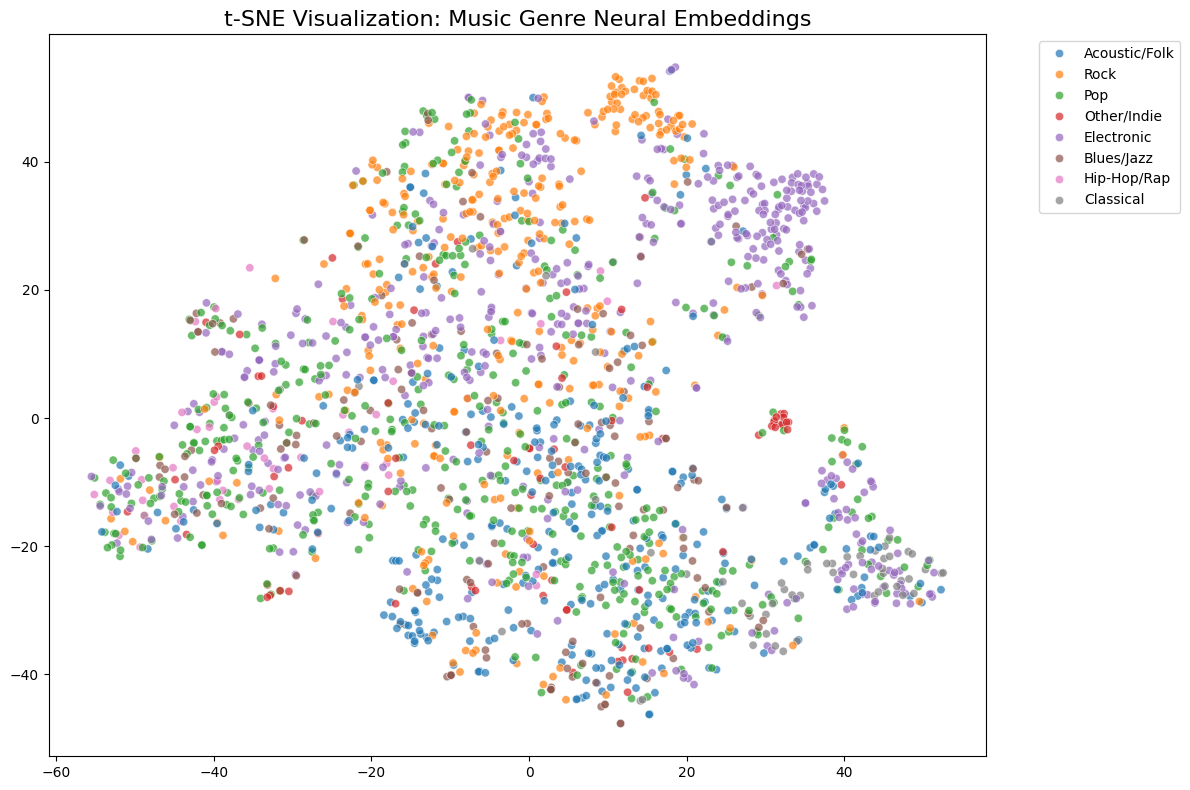

In [19]:
# 1. Access the input directly from the first layer to avoid the AttributeError
# 2. Extract the 256-node hidden layer (which is index 3 in your architecture)
latent_model = Model(inputs=model.layers[0].input, outputs=model.layers[3].output)
# Get embeddings for a sample of the test data (t-SNE is slow on all 22,000 rows)
sample_size = 2000
X_sample = X_test_scaled[:sample_size]
y_sample_labels = mlb.inverse_transform(y_test[:sample_size])

# Grab the primary genre for coloring purposes
primary_labels = [labels[0] if len(labels) > 0 else 'Other/Indie' for labels in y_sample_labels]
latent_features = latent_model.predict(X_sample)

# Run t-SNE to squash 256 dimensions down to 2
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(latent_features)

# Plot the results
plt.figure(figsize=(12, 8))
sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], hue=primary_labels, palette='tab10', alpha=0.7)
plt.title('t-SNE Visualization: Music Genre Neural Embeddings', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

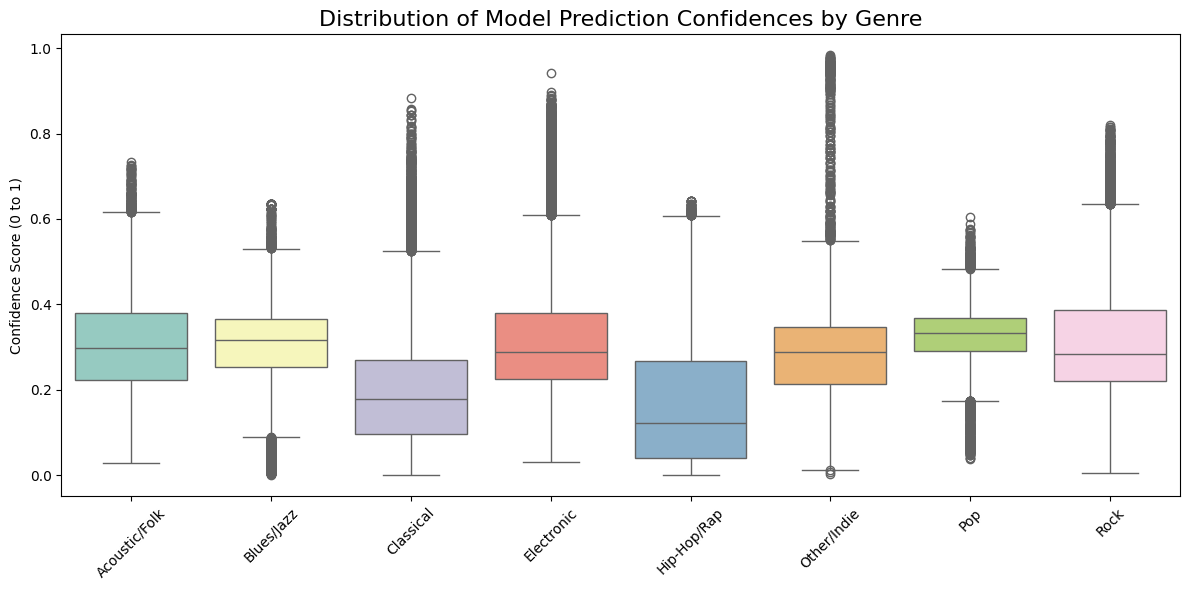

In [20]:
# --- 2. BOX PLOT OF CONFIDENCE SCORES ---
# Convert predictions back to a dataframe for plotting
probs_df = pd.DataFrame(y_pred_probs, columns=mlb.classes_)

plt.figure(figsize=(12, 6))
sns.boxplot(data=probs_df, palette="Set3")
plt.title("Distribution of Model Prediction Confidences by Genre", fontsize=16)
plt.ylabel("Confidence Score (0 to 1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 12))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 12))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 12))']
  warnings.warn(msg

SHAP Summary for: Acoustic/Folk


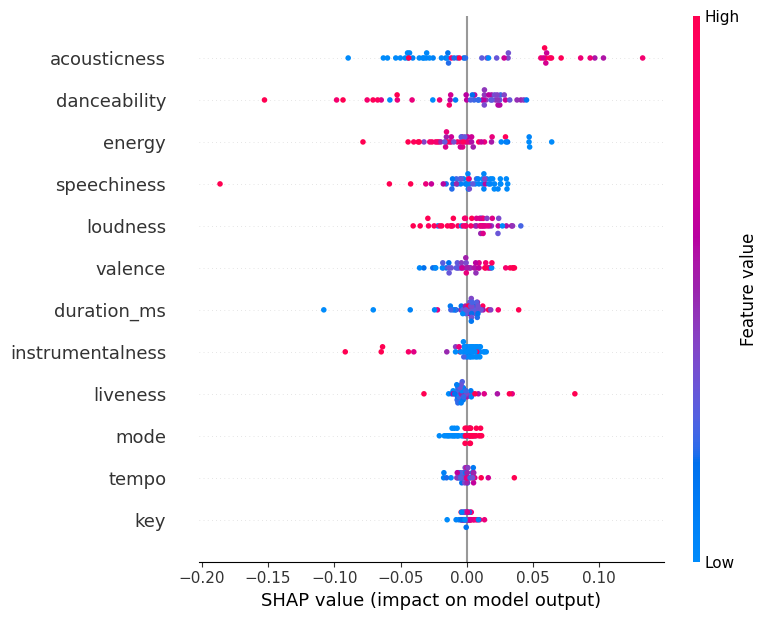

In [21]:
# --- 3. AUTO-DETECT SHAP VISUALIZATION ---
# 1. Use the current model and a small background sample
background = X_train_scaled[:100]
explainer = shap.DeepExplainer(model, background)

# 2. Calculate SHAP values for 50 songs
test_sample = X_test_scaled[:50]
shap_values = explainer.shap_values(test_sample)

# 3. Handle multi-output format based on the returned shape
genre_index = 0
current_feature_names = feature_cols

print(f"SHAP Summary for: {mlb.classes_[genre_index]}")

# FIX: Check if SHAP returned a list or a 3D array
if isinstance(shap_values, list):
    # Older SHAP versions return a list of length 'num_classes'
    shap_values_to_plot = shap_values[genre_index]
else:
    # Newer SHAP versions return a 3D array: (samples, features, classes)
    shap_values_to_plot = shap_values[:, :, genre_index]

# 4. Plot
shap.summary_plot(
    shap_values_to_plot,
    test_sample,
    feature_names=current_feature_names
)

In [22]:
# --- NEW: UNSUPERVISED AUTOENCODER ---
input_dim = X_train_scaled.shape[1] # 12 features

# Encoder
input_layer = layers.Input(shape=(input_dim,))
encoded = layers.Dense(8, activation='relu')(input_layer)
bottleneck = layers.Dense(4, activation='relu', name="bottleneck")(encoded) # 4D Latent Space

# Decoder
decoded = layers.Dense(8, activation='relu')(bottleneck)
output_layer = layers.Dense(input_dim, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# Train it to reconstruct itself (X to X)
autoencoder.fit(X_train_scaled, X_train_scaled, epochs=20, batch_size=128, verbose=0)

# Extract just the encoder part for visualization
encoder_model = Model(inputs=input_layer, outputs=bottleneck)
unsupervised_embeddings = encoder_model.predict(X_visual) # Use the balanced data from Step 1

print("Unsupervised Autoencoder trained and bottleneck features extracted.")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Unsupervised Autoencoder trained and bottleneck features extracted.


In [23]:
# Calculate class weights manually to handle the imbalance
total_samples = len(y_train)
class_weights = {}

for i, class_name in enumerate(mlb.classes_):
    class_count = np.sum(y_train[:, i])
    # The standard formula for balancing weights
    weight = total_samples / (len(mlb.classes_) * class_count)
    class_weights[i] = weight

# Train the model with the weights
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=128,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4204 - loss: 0.0708 - val_accuracy: 0.4310 - val_loss: 0.0761
Epoch 2/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4203 - loss: 0.0705 - val_accuracy: 0.4315 - val_loss: 0.0760
Epoch 3/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4230 - loss: 0.0705 - val_accuracy: 0.4313 - val_loss: 0.0760
Epoch 4/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.4223 - loss: 0.0703 - val_accuracy: 0.4345 - val_loss: 0.0759
Epoch 5/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4238 - loss: 0.0703 - val_accuracy: 0.4350 - val_loss: 0.0761
Epoch 6/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4230 - loss: 0.0702 - val_accuracy: 0.4339 - val_loss: 0.0758
Epoch 7/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4246 - loss: 0.0701 - val_accuracy: 0.4292 - val_loss: 0.0763
Epoch 8/25
456/456 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.4232 - loss: 0.0701 - val_accu

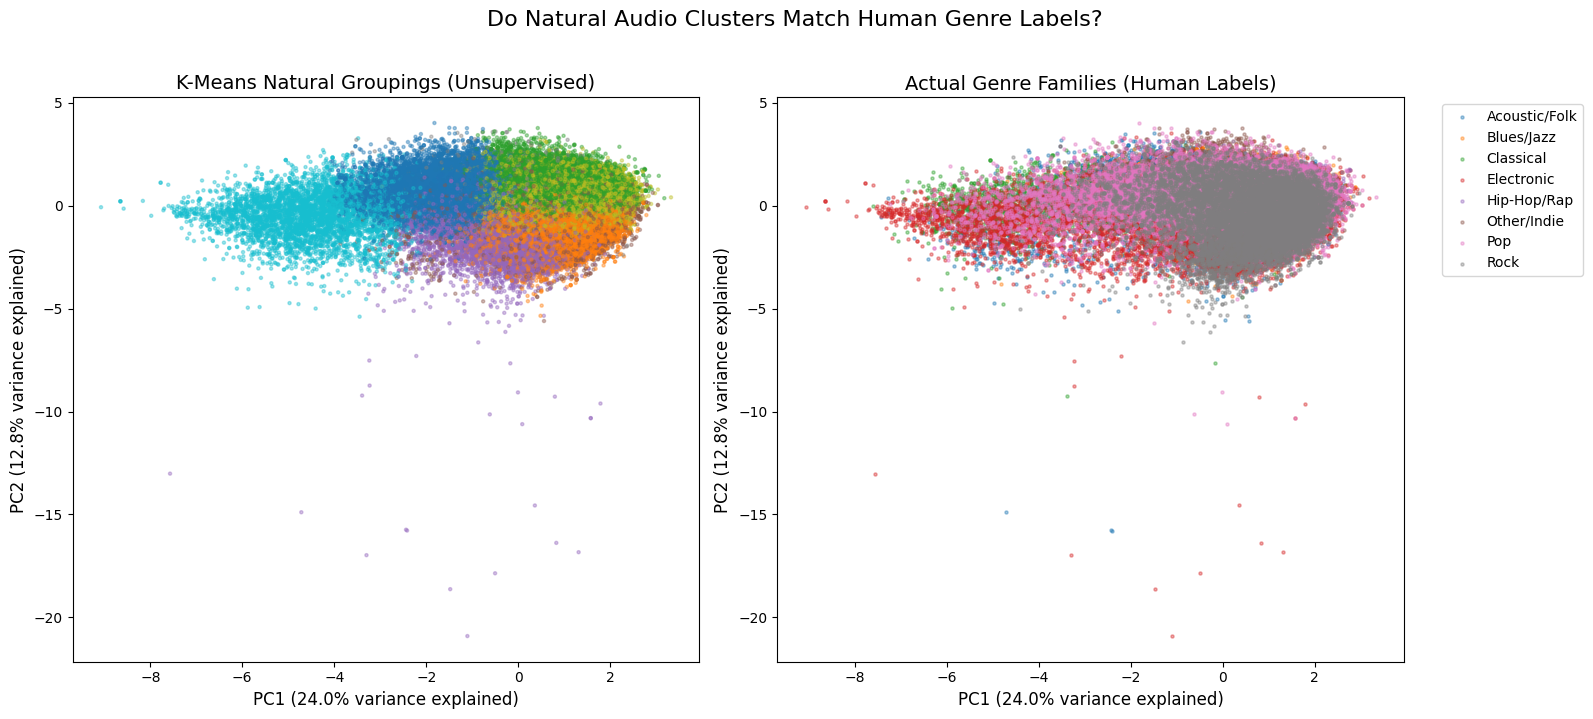

In [24]:
# --- FIXED: K-MEANS + PCA PLOT WITH PROPER AXIS LABELS ---
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
var_explained = pca.explained_variance_ratio_

primary_labels = [mlb.classes_[np.argmax(row)] if np.sum(row) > 0 else 'Other/Indie' for row in y_train]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', alpha=0.4, s=5)
axes[0].set_title('K-Means Natural Groupings (Unsupervised)', fontsize=14)
axes[0].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance explained)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance explained)', fontsize=12)

palette = sns.color_palette('tab10', n_colors=len(mlb.classes_))
for i, genre in enumerate(mlb.classes_):
    mask = [l == genre for l in primary_labels]
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], label=genre, alpha=0.4, s=5, color=palette[i])
axes[1].set_title('Actual Genre Families (Human Labels)', fontsize=14)
axes[1].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance explained)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance explained)', fontsize=12)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Do Natural Audio Clusters Match Human Genre Labels?', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

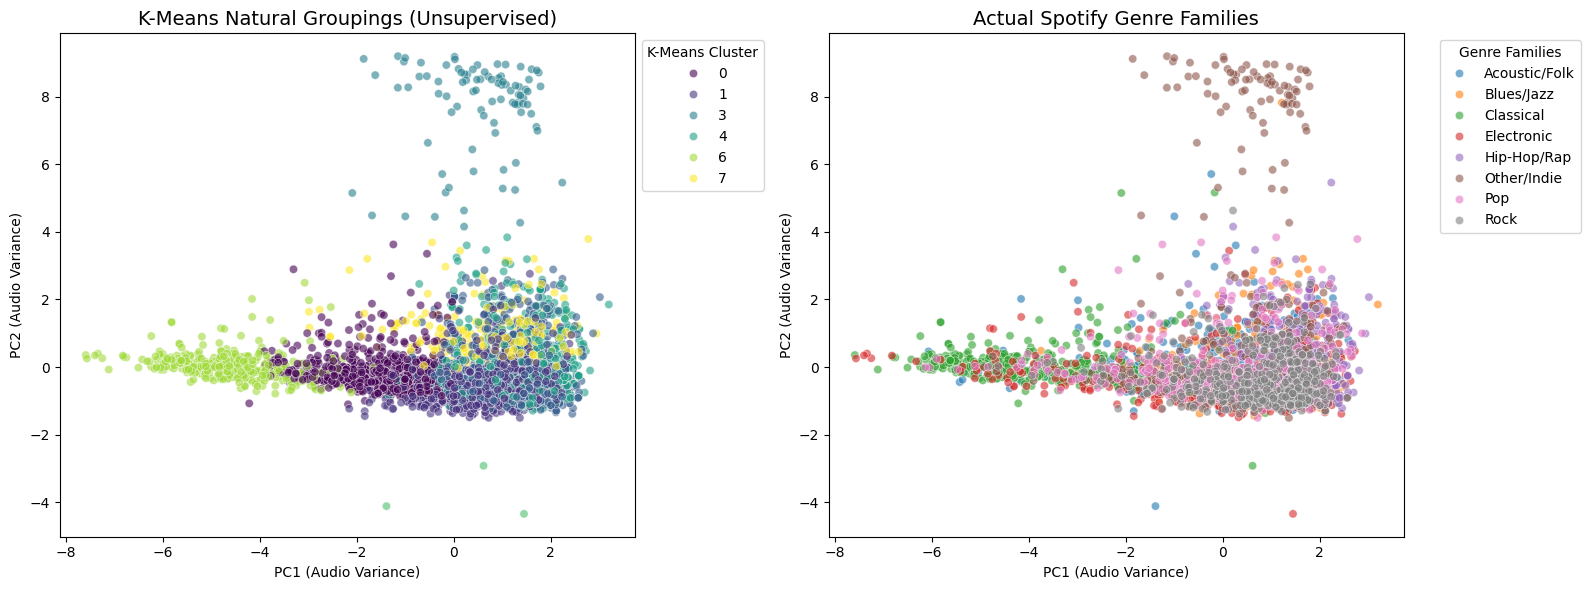

In [25]:
# --- IMPROVED VISUALIZATION: NATURAL VS ACTUAL CLUSTERS ---
pca = PCA(n_components=2)
# Using the balanced data from your earlier Step 1 to prevent 'Indie' dominance
X_pca = pca.fit_transform(X_visual)

plt.figure(figsize=(16, 6))

# Subplot 1: Unsupervised (K-Means)
plt.subplot(1, 2, 1)
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_visual)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', alpha=0.6)
plt.title('K-Means Natural Groupings (Unsupervised)', fontsize=14)
plt.xlabel('PC1 (Audio Variance)')
plt.ylabel('PC2 (Audio Variance)')
plt.legend(title="K-Means Cluster", bbox_to_anchor=(1.0, 1), loc='upper left')

# Subplot 2: Actual Genres
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_visual_labels, palette='tab10', alpha=0.6)
plt.title('Actual Spotify Genre Families', fontsize=14)
plt.xlabel('PC1 (Audio Variance)')
plt.ylabel('PC2 (Audio Variance)')
# The legend is moved outside to the right to prevent overlap
plt.legend(title="Genre Families", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [26]:


# Prepare data for Sankey: Count flows from original genre to family
sankey_data = data.groupby(['track_genre', 'genre_family']).size().reset_index(name='count')

# Create labels (unique list of all original genres + families)
all_nodes = list(sankey_data['track_genre'].unique()) + list(sankey_data['genre_family'].unique())
node_map = {name: i for i, name in enumerate(all_nodes)}

fig = go.Figure(data=[go.Sankey(
    node = dict(pad = 15, thickness = 20, line = dict(color = "black", width = 0.5), label = all_nodes),
    link = dict(
        source = sankey_data['track_genre'].map(node_map),
        target = sankey_data['genre_family'].map(node_map),
        value = sankey_data['count']
    ))])

fig.update_layout(title_text="Genre Mapping Transparency: 114 Sub-genres to 8 Families", font_size=10)
fig.show()

## Unsupervised Autoencoder

Epoch 1/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.5422 - val_loss: 0.3433
Epoch 2/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3189 - val_loss: 0.3020
Epoch 3/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2921 - val_loss: 0.2803
Epoch 4/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2725 - val_loss: 0.2621
Epoch 5/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2552 - val_loss: 0.2478
Epoch 6/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2431 - val_loss: 0.2377
Epoch 7/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2345 - val_loss: 0.2304
Epoch 8/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2276 - val_loss: 0.2253
Epoch 9/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2220 - val_loss: 0.2198
Epoch 10/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2167 - val_loss: 0.2138
Epoch 11/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2119 - val_loss: 0.2092
Epoch 12/30
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

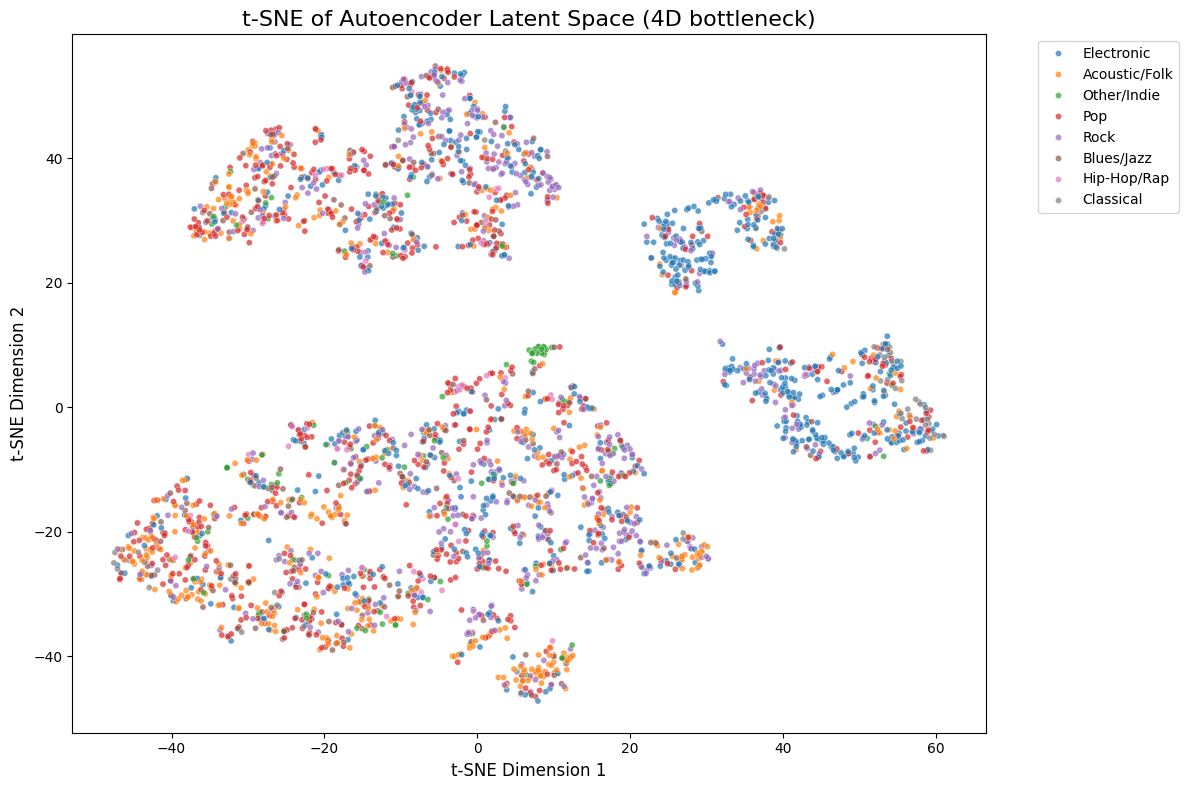

In [27]:
input_dim = X_train_scaled.shape[1]  # 12 features
encoding_dim = 4  # bottleneck

# Build symmetric autoencoder
inputs = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(inputs)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(encoding_dim, activation='relu', name='bottleneck')(encoded)  # 4D latent space
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
outputs = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs, outputs)
encoder = Model(inputs, bottleneck)  # encoder-only model for later

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_train_scaled, X_train_scaled,
                epochs=30, batch_size=256,
                validation_split=0.1, verbose=1)

# Get latent representations
latent_train = encoder.predict(X_train_scaled)
print("Latent space shape:", latent_train.shape)

# t-SNE on latent space (balanced sample)
sample_n = 3000
idx = np.random.choice(len(X_train_scaled), sample_n, replace=False)
latent_sample = latent_train[idx]
labels_sample = [mlb.classes_[np.argmax(row)] if np.sum(row) > 0 else 'Other/Indie' for row in y_train[idx]]

tsne_ae = TSNE(n_components=2, random_state=42, perplexity=40)
tsne_ae_results = tsne_ae.fit_transform(latent_sample)

plt.figure(figsize=(12, 8))
sns.scatterplot(x=tsne_ae_results[:,0], y=tsne_ae_results[:,1],
                hue=labels_sample, palette='tab10', alpha=0.7, s=20)
plt.title('t-SNE of Autoencoder Latent Space (4D bottleneck)', fontsize=16)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [28]:


# 1. Create a shuffled version of your labels
y_train_permuted = np.random.permutation(y_train)
y_test_permuted = np.random.permutation(y_test)

# 2. Re-initialize a fresh version of your model
# (using the same architecture from your 4/13 refinement)
permuted_model = keras.models.clone_model(model)
permuted_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# 3. Train on the "Fake" labels
permuted_history = permuted_model.fit(
    X_train_scaled, y_train_permuted,
    validation_split=0.2,
    epochs=15, # Shorter run is enough for a sanity check
    batch_size=128,
    verbose=0
)

# 4. Compare Results
print(f"Original Model Accuracy: {history.history['accuracy'][-1]:.2f}")
print(f"Permuted (Random) Accuracy: {permuted_history.history['accuracy'][-1]:.2f}")

Original Model Accuracy: 0.43
Permuted (Random) Accuracy: 0.25


In [29]:
# Assuming you already ran the 'encoder_model' from your Step 13
# 1. Transform your raw 12 features into the 4D Latent Space
X_train_latent = encoder_model.predict(X_train_scaled)
X_test_latent = encoder_model.predict(X_test_scaled)

# 2. Build a smaller Classifier that takes these 4 inputs instead of 12
latent_classifier = keras.Sequential([
    layers.Input(shape=(4,)), # The 4 dimensions from your bottleneck
    layers.Dense(64, activation="relu"),
    layers.Dense(y_train.shape[1], activation="sigmoid")
])

latent_classifier.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
# Train this to see if "Compressed Audio" is better at distinguishing genres

2280/2280 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


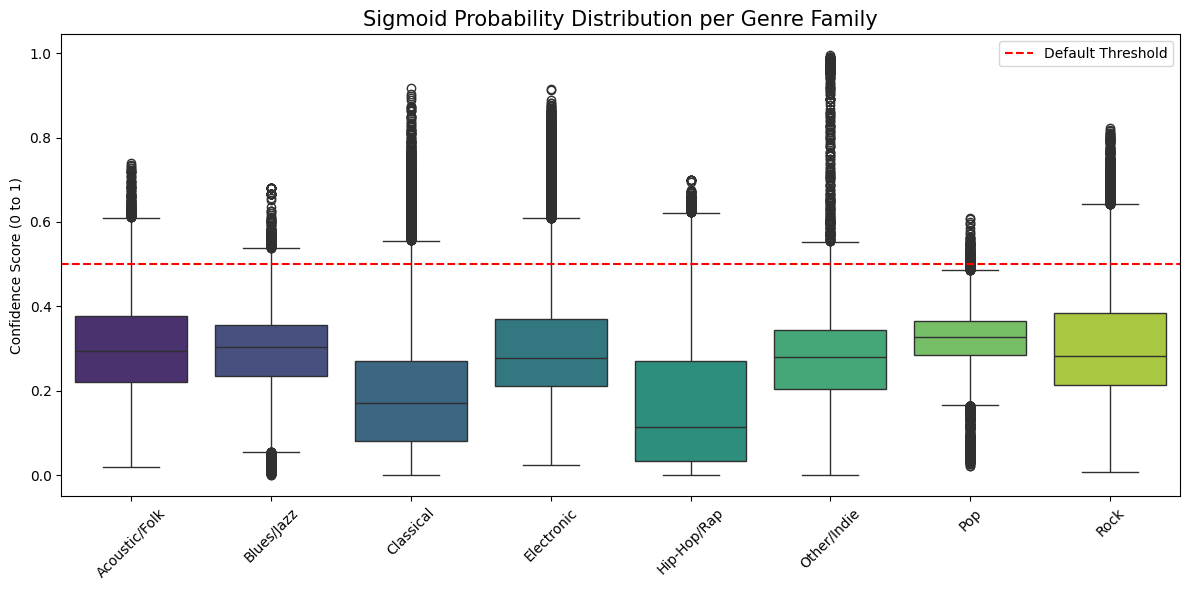

In [30]:
# 1. Get raw sigmoid probabilities from the test set
y_pred_probs = model.predict(X_test_scaled)

# 2. Create a DataFrame for easy plotting
probs_df = pd.DataFrame(y_pred_probs, columns=mlb.classes_)

# 3. Generate the Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=probs_df, palette="viridis")
plt.title("Sigmoid Probability Distribution per Genre Family", fontsize=15)
plt.ylabel("Confidence Score (0 to 1)")
plt.xticks(rotation=45)
plt.axhline(0.5, color='red', linestyle='--', label='Default Threshold')
plt.legend()
plt.tight_layout()
plt.show()

713/713 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


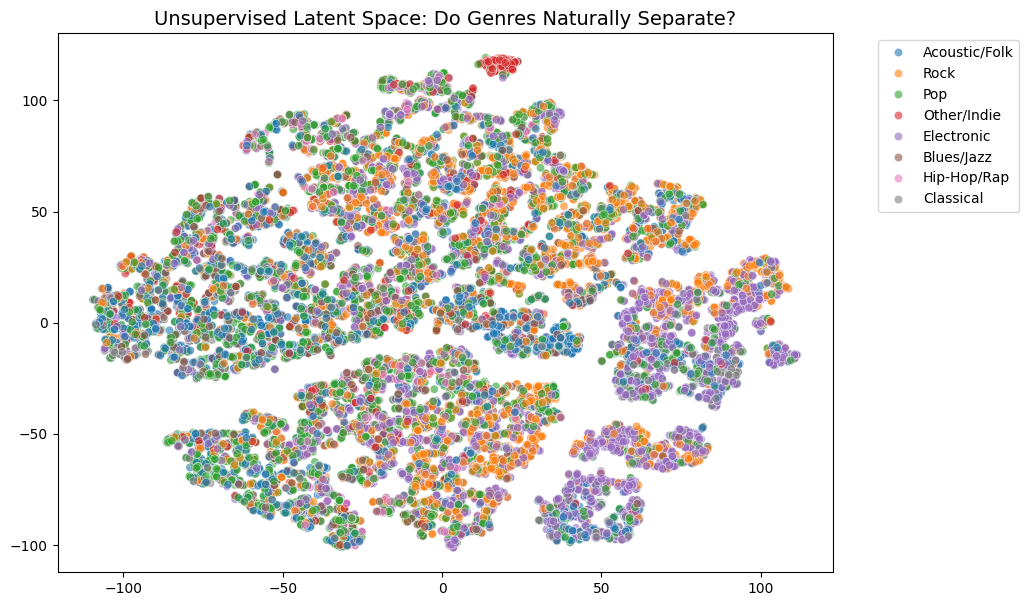

In [31]:
# 1. Extract the 4D latent features from your existing encoder
# (Assuming 'encoder' model from Step 24 of your Colab is defined)
latent_features = encoder.predict(X_test_scaled)

# 2. Use t-SNE to visualize how these 4 dimensions cluster
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(latent_features)

# 3. Plot it colored by your 8 Genre Families
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_results[:,0], y=tsne_results[:,1],
    hue=[mlb.classes_[np.argmax(y)] for y in y_test],
    palette="tab10", alpha=0.6
)
plt.title("Unsupervised Latent Space: Do Genres Naturally Separate?", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [32]:
def find_hidden_gems(genre_name, num_samples=5):
    # Find songs where the model is highly confident in a genre
    # but it might not be the 'primary' label
    genre_idx = list(mlb.classes_).index(genre_name)
    high_conf_indices = np.where(y_pred_probs[:, genre_idx] > 0.7)[0]

    print(f"--- AI Recommended 'Hidden Gems' for {genre_name} ---")
    for i in high_conf_indices[:num_samples]:
        # Connect back to the original dataframe for names
        original_idx = X_test.index[i]
        print(f"🎵 {data.loc[original_idx, 'track_name']} by {data.loc[original_idx, 'artists']}")

# Example use:
find_hidden_gems("Other/Indie")

--- AI Recommended 'Hidden Gems' for Other/Indie ---
🎵 Please Stop Communicating by Joe DeRosa
🎵 Obama and Hitler! by Jamie Kilstein
🎵 Accidental Soccer Coach by Dry Bar Comedy
🎵 The Muppet Show Theme by Little Apple Band
🎵 My Little Pony by Patton Oswalt


In [33]:
# --- ADD THIS: DNA VISUALIZER ---
def plot_radar_dna(song_index):
    probs = model.predict(X_test_scaled[song_index:song_index+1])[0]
    categories = mlb.classes_

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(
          r=probs,
          theta=categories,
          fill='toself',
          name='Genre Probability'
    ))
    fig.update_layout(
      polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
      showlegend=False,
      title=f"Music DNA Radar: Song #{song_index}"
    )
    fig.show()

plot_radar_dna(42)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning:

Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 12))']

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 12))']

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(10, 12))']



SHAP Explanation for Acoustic/Folk:


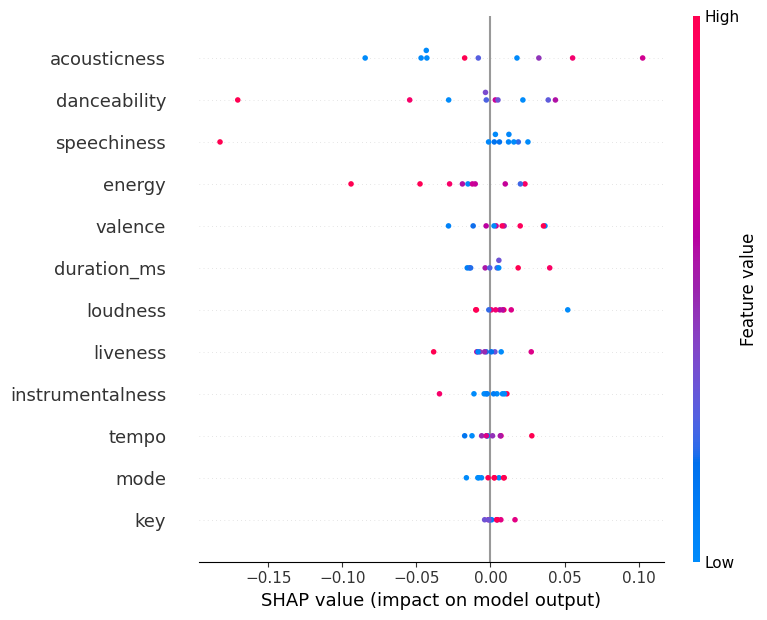

In [34]:
# 1. Select a small background sample (DeepExplainer needs this as a baseline)
background = X_train_scaled[:100]
explainer = shap.DeepExplainer(model, background)

# 2. Calculate SHAP values for the first 10 songs in the test set
test_sample = X_test_scaled[:10]
shap_values = explainer.shap_values(test_sample)

# 3. FIX: Determine if we have a list (older SHAP) or 3D array (newer SHAP)
# We want all samples, all features, but only the FIRST genre (index 0)
if isinstance(shap_values, list):
    # List format: shap_values[genre_index] is (10, 12)
    shap_values_to_plot = shap_values[0]
else:
    # 3D Array format: shap_values[:, :, genre_index] is (10, 12)
    # The shape is (samples, features, classes)
    shap_values_to_plot = shap_values[:, :, 0]

# 4. Generate the plot
print(f"SHAP Explanation for {mlb.classes_[0]}:")
shap.summary_plot(shap_values_to_plot, test_sample, feature_names=feature_cols)

## Identifying the Standard

In [35]:

# 1. Calculate Confidence and Margins
# 'top_prob' is the highest sigmoid score for each song
top_prob = np.max(y_test_probs, axis=1)
top_pred_idx = np.argmax(y_test_probs, axis=1)
true_label_idx = np.argmax(y_test, axis=1)

# Correctness mask
is_correct = (top_pred_idx == true_label_idx)

# 2. Find the "Gold Standard" (Highest Confidence + Correct)
results_df = pd.DataFrame({
    'test_index': np.arange(len(y_test)),
    'actual': [mlb.classes_[i] for i in true_label_idx],
    'predicted': [mlb.classes_[i] for i in top_pred_idx],
    'confidence': top_prob,
    'correct': is_correct
})

gold_standards = results_df[results_df['correct']].sort_values(by='confidence', ascending=False).head(5)

# 3. Find the "Genre-Benders" (Most Confused)
# We look for the smallest margin between the 1st and 2nd highest prediction
sorted_probs = np.sort(y_test_probs, axis=1)
margin = sorted_probs[:, -1] - sorted_probs[:, -2]
results_df['margin'] = margin

confused_tracks = results_df.sort_values(by='margin', ascending=True).head(5)

print("--- TOP 5 GOLD STANDARDS (Highest Accuracy) ---")
display(gold_standards)

print("\n--- TOP 5 GENRE-BENDERS (Most Confused/Overlap) ---")
display(confused_tracks)

--- TOP 5 GOLD STANDARDS (Highest Accuracy) ---


,test_index,actual,predicted,confidence,correct
14987,14987,Other/Indie,Other/Indie,0.983278,True
2574,2574,Other/Indie,Other/Indie,0.980710,True
4541,4541,Other/Indie,Other/Indie,0.978283,True
22711,22711,Other/Indie,Other/Indie,0.977478,True
21777,21777,Other/Indie,Other/Indie,0.976735,True



--- TOP 5 GENRE-BENDERS (Most Confused/Overlap) ---


,test_index,actual,predicted,confidence,correct,margin
14048,14048,Pop,Blues/Jazz,0.410627,False,0.000006
20282,20282,Electronic,Electronic,0.440242,True,0.000008
710,710,Electronic,Electronic,0.456404,True,0.000015
18677,18677,Acoustic/Folk,Hip-Hop/Rap,0.415528,False,0.000020
4443,4443,Acoustic/Folk,Pop,0.355518,False,0.000028


## Simulated Timeline Prediction (Performance by Day)

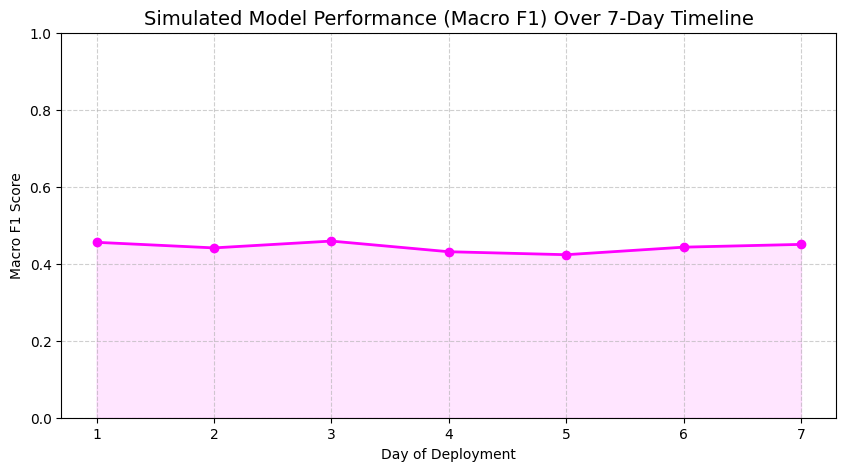

In [36]:


# Simulate 7 days of incoming data from the test set
days = 7
batch_size = len(y_test) // days
timeline_metrics = []

for d in range(days):
    start, end = d * batch_size, (d + 1) * batch_size
    y_true_batch = y_test[start:end]
    y_pred_batch = y_pred[start:end]

    # Calculate Macro F1 for this "day"
    score = f1_score(y_true_batch, y_pred_batch, average='macro')
    timeline_metrics.append(score)

# Plotting the Timeline
plt.figure(figsize=(10, 5))
plt.plot(range(1, days + 1), timeline_metrics, marker='o', linestyle='-', color='magenta', linewidth=2)
plt.fill_between(range(1, days + 1), timeline_metrics, alpha=0.1, color='magenta')
plt.title('Simulated Model Performance (Macro F1) Over 7-Day Timeline', fontsize=14)
plt.xlabel('Day of Deployment')
plt.ylabel('Macro F1 Score')
plt.ylim(0, 1) # Show full scale to be honest about performance
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Visualizing the 'Certainty Gap'...


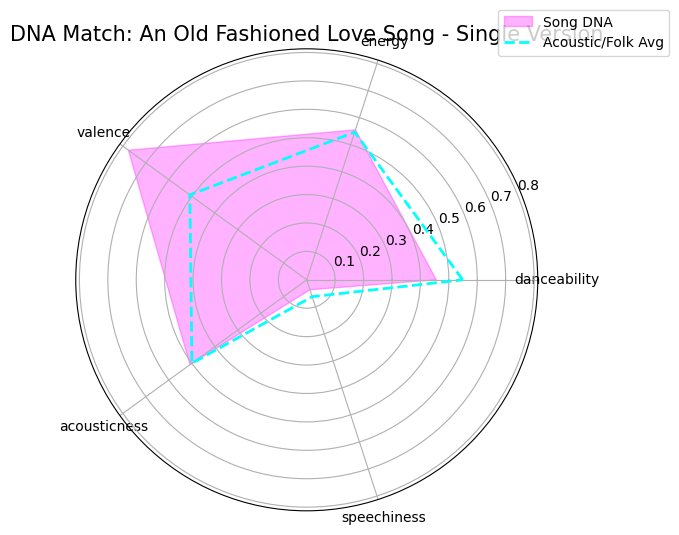

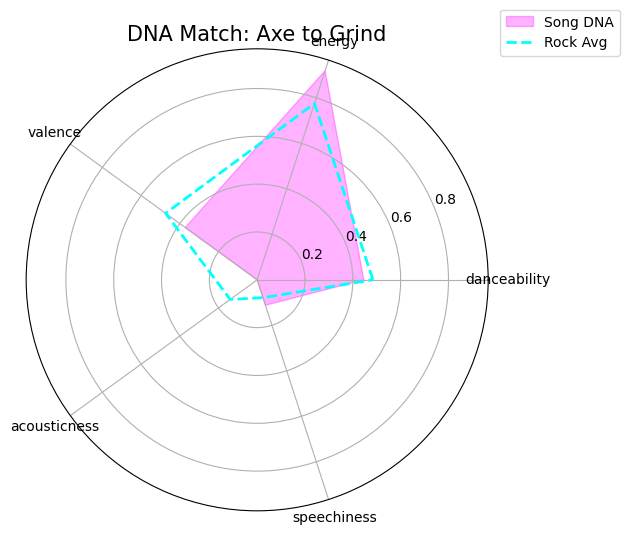

In [37]:
# Run this for your Gold Standard #19798 and Genre-Bender #22714
print("Visualizing the 'Certainty Gap'...")
plot_dna_comparison(19798) # The Gold Standard
plot_dna_comparison(22714) # The Genre-Bender

--- Top 5 Acoustic Relatives for 'Hark The Herald Angels Sing' ---
🎵 Hark The Herald Angels Sing by Hawk Nelson | Genre: Rock | Similarity: 100.00%
🎵 Só Lazer by Charlie Brown Jr. | Genre: Rock | Similarity: 100.00%
🎵 「君と私の歌」 by =LOVE | Genre: Pop | Similarity: 99.97%
🎵 恋夜 by neguse. | Genre: Pop | Similarity: 99.97%
🎵 バイリンガール by go!go!vanillas | Genre: Pop | Similarity: 99.96%


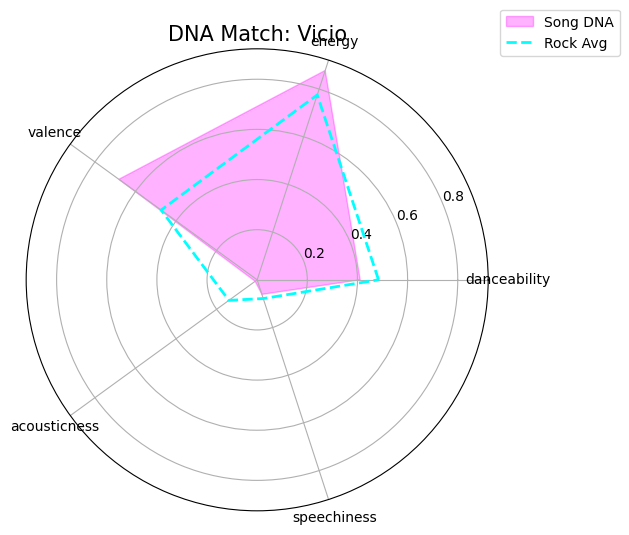

In [41]:
# Comparing Song #42 to the rest of the training set in the Latent Space
# The index 42 refers to the 42nd song in the X_train_scaled (and thus latent_train) array.
# We need to map this back to the original 'data' DataFrame index.
target_song_array_index = 42
original_target_song_idx_in_data = X_train.index[target_song_array_index]

song_dna = latent_train[target_song_array_index].reshape(1, -1)
similarities = cosine_similarity(song_dna, latent_train)

# This finds the 'Acoustic Relatives' of any song within the *training set*
top_matches_indices_in_latent_train = np.argsort(similarities[0])[-5:]

# --- STEP 2: PRINT THE RESULTS ---
print(f"--- Top 5 Acoustic Relatives for '{data.loc[original_target_song_idx_in_data, 'track_name']}' ---")

# We loop through the top matches found by cosine similarity
for match_idx_in_latent_train in top_matches_indices_in_latent_train[::-1]: # Reverse to show most similar first
    # Map back to the original dataframe index using X_train.index
    actual_idx_in_data = X_train.index[match_idx_in_latent_train]
    song_name = data.loc[actual_idx_in_data, 'track_name']
    artist = data.loc[actual_idx_in_data, 'artists']
    genre = data.loc[actual_idx_in_data, 'genre_family']

    # Calculate the similarity percentage for the display
    sim_score = similarities[0][match_idx_in_latent_train] * 100
    print(f"🎵 {song_name} by {artist} | Genre: {genre} | Similarity: {sim_score:.2f}%")

# --- STEP 3: VISUAL DNA OVERLAY ---
# This visually proves why they are similar even if their 'Human Labels' differ
# Plot the DNA comparison for the original target song
plot_dna_comparison(original_target_song_idx_in_data)
